# LeNet-5 Architecture with PyTorch

This notebook contains the implementation of the LeNet-5 neural network architecture using PyTorch, as proposed by Yann LeCun et al. in 1998.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

## Defining the LeNet-5 Model Structure

In [8]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # C1 Convolutional Layer: 1 input channel, 6 output channels, 5x5 kernel, padding=2
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        # S2 Subsampling (Pooling) Layer: Max pooling with 2x2 kernel, stride=2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # C3 Convolutional Layer: 6 input channels, 16 output channels, 5x5 kernel, stride=1
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        # S4 Subsampling (Pooling) Layer: Max pooling with 2x2 kernel, stride=2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # C5 Convolutional Layer (Fully Connected): 16 input channels, 120 output channels, 5x5 kernel
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        
        # F6 Fully Connected Layer: 120 input features, 84 output features
        self.fc1 = nn.Linear(120, 84)
        # Output Layer: 84 input features, num_classes output features
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        # Layer 1: Conv -> Activation -> Pool
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        
        # Layer 2: Conv -> Activation -> Pool
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        # Layer 3: Conv (effectively Dense) -> Activation
        x = F.relu(self.conv3(x))
        
        # Flatten for Dense layers
        x = x.view(x.size(0), -1)
        
        # Layer 4: Dense -> Activation
        x = F.relu(self.fc1(x))
        
        # Layer 5: Output Dense layer
        x = self.fc2(x)
        
        return x

100.0%
100.0%
100.0%
100.0%


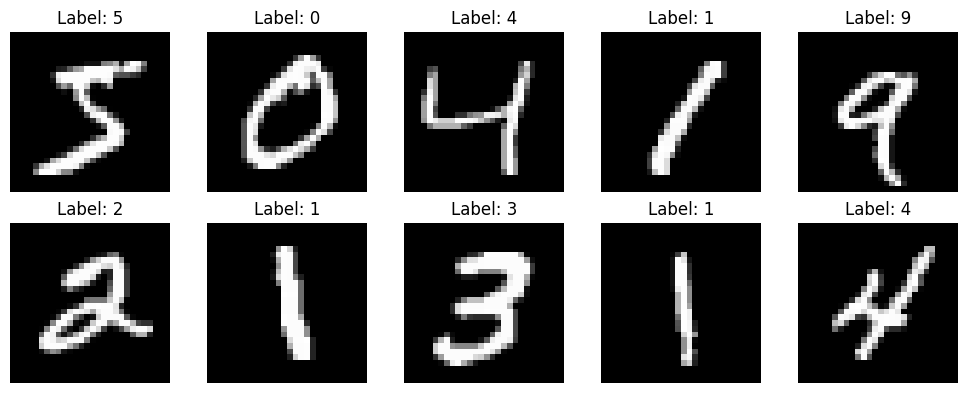

In [11]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    image, label = mnist_train[i]
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
from torch.utils.data import DataLoader

batch_size = 64
epochs = 5
learning_rate = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)

model = LeNet5(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

model.train()
for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.2f}%")

Epoch [1/5] - Loss: 0.2943 - Acc: 90.92%
Epoch [2/5] - Loss: 0.0836 - Acc: 97.36%
Epoch [3/5] - Loss: 0.0578 - Acc: 98.19%
Epoch [4/5] - Loss: 0.0451 - Acc: 98.52%
Epoch [5/5] - Loss: 0.0365 - Acc: 98.87%
